In [1]:
%load_ext autoreload
%autoreload 2

from subareas import Subareas
from subarea_calculations import Subarea_Calculations
from bond_simulation import bond_simulation

from climada.hazard import TCTracks, Centroids, TropCyclone
from climada.entity import LitPop
from climada.entity import ImpfSetTropCyclone
import numpy as np



### Set CAT Bond Basics

In [2]:
### Bond Basics ###
country = 659  # St. Kitts and Nevis
exhaustion_point = 0.5 # 50% of exposure
attachment_point = 0.05 # 5% of exposure
exhaustion_point_method = 'Exposure_Share' # 50% of exposure
attachment_point_method = 'Exposure_Share' # 5% of exposure
term = 3  # years
par_index = 60 # statistic for parametric index (e.g. 60 for 60th percentile)

### Subarea Basics ###
grid_specs=[1,2] # 3x3 grid
buffer_grid_size=0.5 # km of buffer around exposure
min_pol_size=100 # minimum subarea size in m² 

### Pricing Basics ###
peak_peril = 0 # indicator if its considered peak peril (1) or not (0)
target_sharpe = 0.5 # target Sharpe ratio
risk_free_rate = 0.0  # risk free rate for Sharpe ratio and return calculation

### Define Exposure, Hazard, and Vulnerability

In [3]:
tr_irma = TCTracks.from_ibtracs_netcdf(
    provider="usa", storm_id="2017242N16333"
)  # IRMA 2017
tr_irma.equal_timestep()
tr_irma.calc_perturbed_trajectories(nb_synth_tracks=50)
min_lat, max_lat, min_lon, max_lon = 17.0, 17.5, -62.9, -62.5
cent = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res=0.02)

# construct tropical cyclones
tc_irma = TropCyclone.from_tracks(tr_irma, centroids=cent)


exp = LitPop.from_countries(
        [str(country)], fin_mode='gdp', reference_year=2020
    )

impfset = ImpfSetTropCyclone.from_calibrated_regional_ImpfSet()
iso3n_per_region = impf_id_per_region = impfset.get_countries_per_region()[2]
exp.gdf.loc[exp.gdf.region_id == country, 'impf_TC'] = 1

# change dates of tc events to allow simulation of multiple years
tc_irma.date = np.array([736576, 736596, 736649, 736659, 736668, 736681, 736701, 736702, 736715, 736726,
 736727, 736731, 736743, 736753, 736762, 736781, 736787, 736803, 736808, 736821,
 736843, 736848, 736854, 736868, 736872, 736878, 736892, 736900, 736904, 736912,
 736921, 736926, 736940, 736945, 736952, 736963, 736976, 736983, 736993, 737003,
 737012, 737020, 737031, 737037, 737048, 737059, 737068, 737074, 737081, 737092,
 737098])

2025-11-07 15:27:54,824 - climada.hazard.tc_tracks - INFO - Progress: 100%
2025-11-07 15:27:54,989 - climada.hazard.tc_tracks - INFO - Interpolating 1 tracks to 1h time steps.
2025-11-07 15:27:55,091 - climada.hazard.tc_tracks_synth - INFO - Computing 50 synthetic tracks.


<string>:7: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.


2025-11-07 15:28:03,073 - climada.util.coordinates - INFO - Sampling from /Users/kbergmueller/climada/data/GMT_intermediate_coast_distance_01d.tif
2025-11-07 15:28:03,338 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Mapping 51 tracks to 546 coastal centroids.
2025-11-07 15:28:04,253 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 11%
2025-11-07 15:28:05,117 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 23%
2025-11-07 15:28:05,885 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 35%
2025-11-07 15:28:06,870 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 47%
2025-11-07 15:28:07,616 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 58%
2025-11-07 15:28:09,211 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 70%
2025-11-07 15:28:10,170 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 82%
2025-11-07 15:28:11,194 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 94%
2025-11-07 15

### Initialise Subarea Class

2025-11-07 15:28:15,506 - climada.util.coordinates - INFO - Raster from resolution 0.00833332999999925 to 0.00833332999999925.


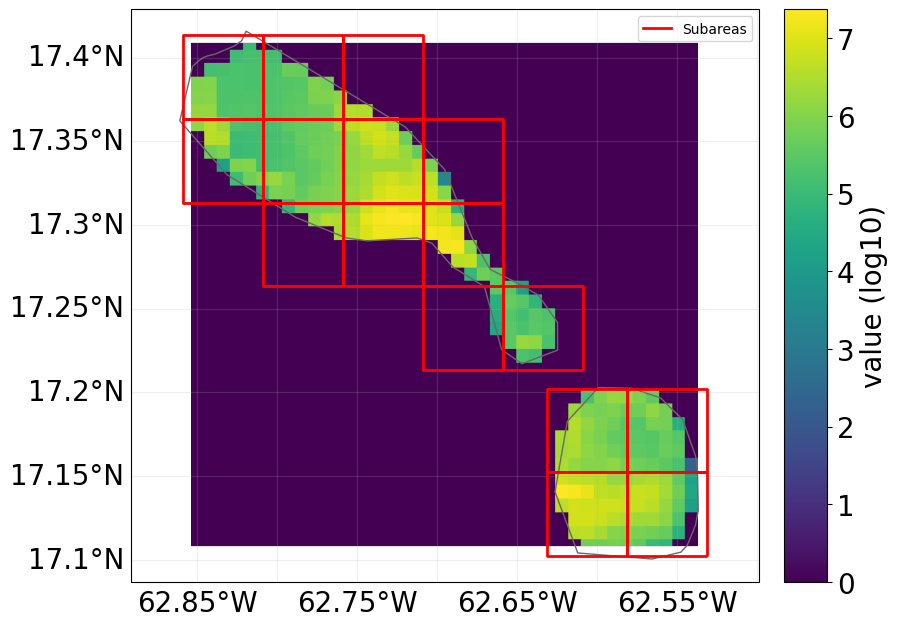

In [4]:
st_kitts_subareas = Subareas(tc_irma, impfset, exp, resolution=0.05, buffer_grid_size=buffer_grid_size)
st_kitts_subareas.plot()

### Subarea Calculations

In [5]:
st_kitts_sub_calc = Subarea_Calculations(subareas=st_kitts_subareas, index_stat=par_index)
st_kitts_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method)

2025-11-07 15:28:39,012 - climada.entity.exposures.base - INFO - Matching 328 exposures with 546 centroids.
2025-11-07 15:28:39,017 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 100
2025-11-07 15:28:39,033 - climada.engine.impact_calc - INFO - Calculating impact for 984 assets (>0) and 51 events.


### Bond Simulation

In [6]:
st_kitts_bond_sim = bond_simulation(st_kitts_sub_calc, term, 20, 0.03) 
st_kitts_bond_sim.init_loss_simulation()
st_kitts_bond_sim.init_return_simulation()
display(st_kitts_bond_sim.return_metrics)
display(st_kitts_bond_sim.loss_metrics)

{'annual_premiums': array([2.83731021e-02, 8.73102078e-04, 1.66533454e-18, 2.50000000e-03,
        0.00000000e+00, 0.00000000e+00, 2.50000000e-03, 0.00000000e+00,
        0.00000000e+00, 3.00000000e-02, 3.00000000e-02, 3.00000000e-02,
        3.00000000e-02, 3.00000000e-02, 3.00000000e-02, 3.00000000e-02,
        3.00000000e-02, 3.00000000e-02, 3.00000000e-02, 3.00000000e-02,
        3.00000000e-02, 3.00000000e-02, 3.00000000e-02, 3.00000000e-02,
        3.00000000e-02, 3.00000000e-02, 3.00000000e-02, 3.00000000e-02,
        3.00000000e-02, 3.00000000e-02, 3.00000000e-02, 3.00000000e-02,
        3.00000000e-02, 3.00000000e-02, 3.00000000e-02, 3.00000000e-02,
        3.00000000e-02, 3.00000000e-02, 3.00000000e-02, 3.00000000e-02,
        3.00000000e-02, 3.00000000e-02, 3.00000000e-02, 3.00000000e-02,
        3.00000000e-02, 3.00000000e-02, 3.00000000e-02, 3.00000000e-02,
        3.00000000e-02, 3.00000000e-02, 3.00000000e-02, 3.00000000e-02,
        3.00000000e-02, 3.00000000e-02, 3.000

{'EL_ann': 0.017543859649122806,
 'AP_ann': 0.023391812865497075,
 'Tot_payout': 1325883333.3333325,
 'Tot_damages': 11037139919.100546,
 'VaR_99_ann': 0.7555314181864904,
 'VaR_95_ann': 0.0,
 'ES_99_ann': 1.0,
 'ES_95_ann': 0.75}